## Boxplot

In [16]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt

## 1 Выведем файл с данными.

In [17]:
file = '/Users/cleganeb/Desktop/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/data/ab-test.csv'
file = pd.read_csv(file)

In [18]:
display(file.head())
print(len(file))

,uid,diff,time,group
0,user_1,-103.333333,after,test
1,user_1,-6.000000,before,test
2,user_18,-10.000000,after,test
3,user_18,-3.500000,before,test
4,user_19,-82.333333,after,test


44


 ## 2 Выделим данные для построения Boxplot.

In [19]:
test_data_before = file[(file['group'] == 'test') & (file['time'] == 'before')]
test_data_after = file[(file['group'] == 'test') & (file['time'] == 'after')]
control_data_before = file[(file['group'] == 'control') & (file['time'] == 'before')]
control_data_after = file[(file['group'] == 'control') & (file['time'] == 'after')]

display(test_data_before)
print(len(test_data_before))
display(test_data_after)
print(len(test_data_after))
display(control_data_before)
print(len(control_data_before))
display(control_data_after)
print(len(control_data_after))


,uid,diff,time,group
1,user_1,-6.000000,before,test
3,user_18,-3.500000,before,test
5,user_19,-148.000000,before,test
7,user_21,-112.500000,before,test
9,user_25,-69.333333,before,test
11,user_28,-53.000000,before,test
13,user_3,-70.000000,before,test


7


,uid,diff,time,group
0,user_1,-103.333333,after,test
2,user_18,-10.000000,after,test
4,user_19,-82.333333,after,test
6,user_21,-78.500000,after,test
8,user_25,-127.500000,after,test
10,user_28,-136.500000,after,test
12,user_3,-158.500000,after,test


7


,uid,diff,time,group
15,user_12,-103.0,before,control
17,user_13,-15.5,before,control
19,user_15,-3.0,before,control
21,user_16,-153.0,before,control
23,user_2,-202.0,before,control
25,user_20,-16.0,before,control
27,user_22,-156.0,before,control
29,user_24,-75.0,before,control
31,user_26,-40.0,before,control
33,user_27,-3.5,before,control


15


,uid,diff,time,group
14,user_12,-75.000000,after,control
16,user_13,-81.500000,after,control
18,user_15,-32.000000,after,control
20,user_16,17.500000,after,control
22,user_2,-94.000000,after,control
24,user_20,-49.000000,after,control
26,user_22,-131.666667,after,control
28,user_24,-322.666667,after,control
30,user_26,-77.000000,after,control
32,user_27,-9.000000,after,control


15


## 3 Построим Boxplot.

/var/folders/zz/zyxvpxvq6csfxvn_n00lv4hc04ys43/T/ipykernel_56319/1439912185.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([control_data_after['diff'], test_data_after['diff']],
/var/folders/zz/zyxvpxvq6csfxvn_n00lv4hc04ys43/T/ipykernel_56319/1439912185.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([control_data_before['diff'], test_data_before['diff']],


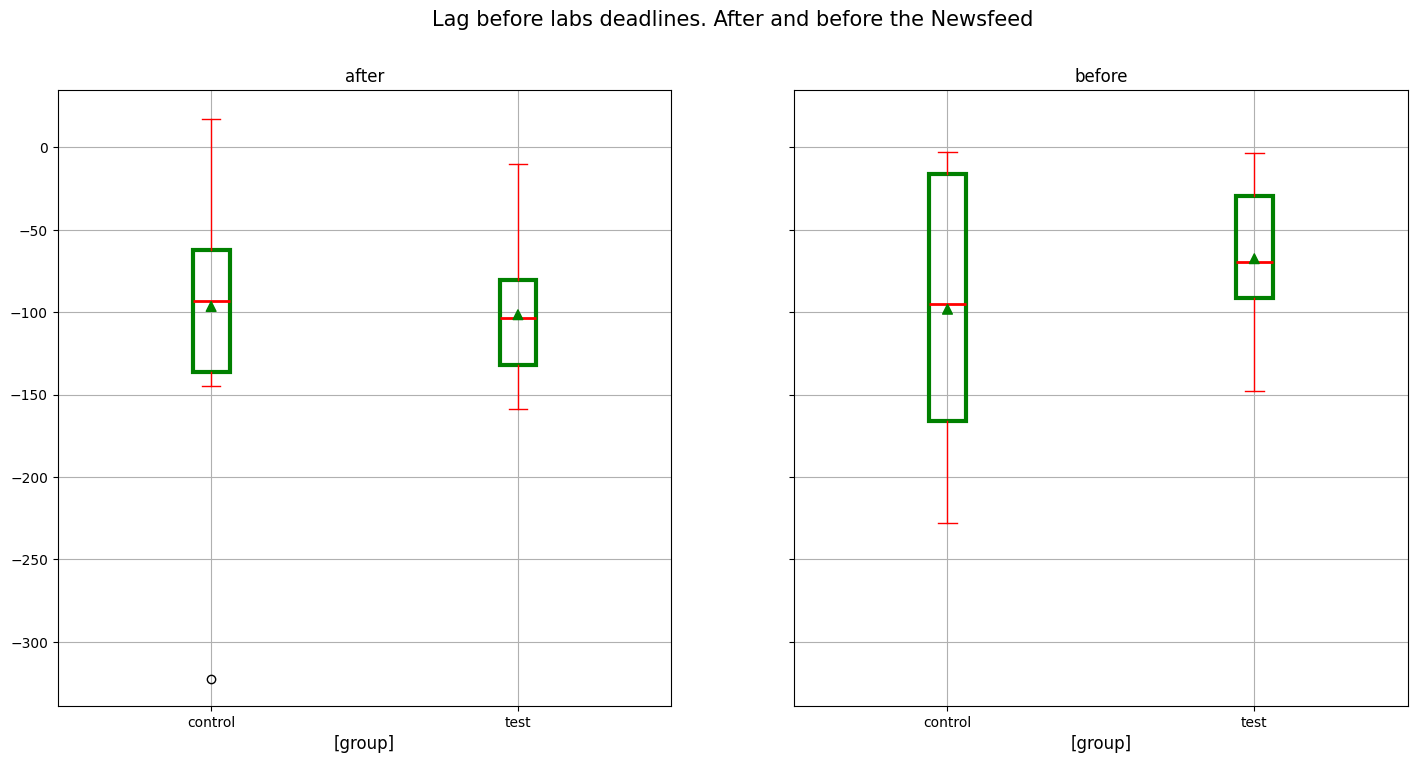

In [20]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 8)) 


axes[0].boxplot([control_data_after['diff'], test_data_after['diff']],
                labels=['control', 'test'],
                widths=0.12,
                boxprops={"facecolor": "none", "edgecolor": "green", "linewidth": 3},
                whiskerprops={"color": "red", "linewidth": 1},
                capprops={"color": "red"},
                medianprops={"color": "red", "linewidth": 2},
                patch_artist=True)
axes[0].set_title('after', fontsize=12)
axes[0].set_xlabel('[group]', fontsize=12)
axes[0].grid(True)

axes[1].boxplot([control_data_before['diff'], test_data_before['diff']],
                labels=['control', 'test'],
                widths=0.12,
                boxprops={"facecolor": "none", "edgecolor": "green", "linewidth": 3},
                whiskerprops={"color": "red", "linewidth": 1},
                capprops={"color": "red"},
                medianprops={"color": "red", "linewidth": 2},
                patch_artist=True)
axes[1].set_title('before', fontsize=12)
axes[1].set_xlabel('[group]', fontsize=12)
axes[1].grid(True)

min_val = min(control_data_before['diff'].min(), control_data_after['diff'].min())
max_val = max(control_data_before['diff'].max(), control_data_after['diff'].max())

axes[0].set_ylim(min_val, max_val)
axes[1].set_ylim(min_val, max_val)
axes[1].tick_params(axis='y', labelleft=False)

for ax in axes:
    ax.set_ylim(min_val * 1.05, max_val * 2)  
    if ax != axes[0]:
        ax.tick_params(axis='y', labelleft=False)

arrowprops = dict(facecolor='green', edgecolor='green', shrink=0.05, width=1, headlength=7, headwidth=7)

def add_arrow(ax, data, groups):
    for i, group in enumerate(groups):
        median = np.percentile(data[i], 50)
        if group == 'test':
            start_point = median - 5  # Основание стрелки находится чуть выше медианы
            ax.annotate('', xy=(i + 1, median + 5),       # Концом стрелки будет медиана
                    xytext=(i + 1, start_point + 5), # Начало стрелки чуть выше медианы
                    arrowprops=arrowprops)
            
        else:
            start_point = median - 5  # Стрелка начинается чуть ниже медианы
            ax.annotate('', xy=(i + 1, median),       # Концом стрелки будет медиана
                    xytext=(i + 1, start_point), # Начало стрелки чуть ниже медианы
                    arrowprops=arrowprops)

add_arrow(axes[0], [control_data_after['diff'], test_data_after['diff']], ['control', 'test'])
add_arrow(axes[1], [control_data_before['diff'], test_data_before['diff']], ['control', 'test'])

plt.suptitle('Lag before labs deadlines. After and before the Newsfeed', fontsize=15)

plt.subplots_adjust(left=0.05, right=0.95, wspace=0.2)

plt.show()




## 4 Каков был межквартильный размах (IQR) контрольной группы до появления новостной ленты?

## На графике это длина самого большого ящика. Примерно 150.